Found 600 images belonging to 10 classes.
Found 150 images belonging to 10 classes.
Found 750 images belonging to 10 classes.
Number of Classes: 10
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.1052 - loss: 2.4006 - val_accuracy: 0.1267 - val_loss: 2.2615
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 359ms/step - accuracy: 0.1389 - loss: 2.2840 - val_accuracy: 0.1533 - val_loss: 2.2237
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 391ms/step - accuracy: 0.1216 - loss: 2.3023 - val_accuracy: 0.3400 - val_loss: 2.1754
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 362ms/step - accuracy: 0.1800 - loss: 2.2409 - val_accuracy: 0.3867 - val_loss: 2.1464
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 370ms/step - accuracy: 0.1940 - loss: 2.1881 - val_accuracy: 0.4933 - val_loss: 2.1075
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step - accuracy: 0.2531 - loss: 2.1464 - val_accuracy: 0.5000 - val_loss: 2.0630
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 365ms/step - accuracy: 0.2200 - loss

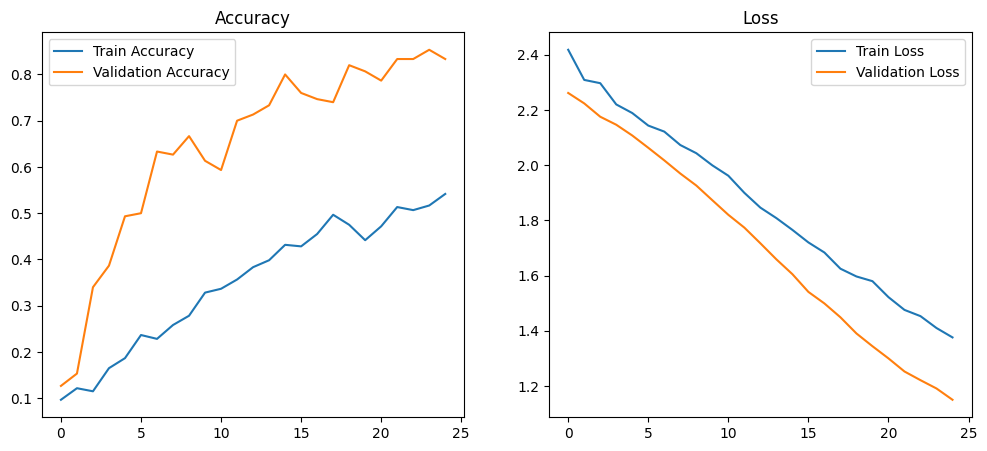

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.9206 - loss: 1.0561
Validation Accuracy: 82.00%
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.9332 - loss: 0.9441
Test Accuracy: 84.93%


In [58]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Dataset Path
data_dir = '/kaggle/input/swedishleaf/SwedishLeaf'  # Replace with the correct dataset path

# Parameters
img_size = (224, 224)  # Resize images to 224x224 for VGG16 compatibility
batch_size = 16

# Data Generators with Splitting
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of data for validation
)

# Training Generator
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation Generator
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Test Generator (Separate Subdirectory Assumed for Testing)
test_generator = ImageDataGenerator(rescale=1.0 / 255.0).flow_from_directory(
    data_dir,  # Replace with the correct test dataset path, if separate
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Dynamically Determine Number of Classes
num_classes = train_generator.num_classes
print(f"Number of Classes: {num_classes}")

# Load Pre-trained VGG16 Model
local_weights_path = "/kaggle/input/vgg16-ds/vgg16_weights_tf_dim_ordering_tf_kernels_notop (7).h5"
vgg16 = VGG16(weights=local_weights_path, include_top=False, input_shape=(224, 224, 3))
for layer in vgg16.layers:
    layer.trainable = False

# Add Custom Classification Layers
model = Sequential([
    vgg16,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the Model
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

# Evaluate on Validation Set
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


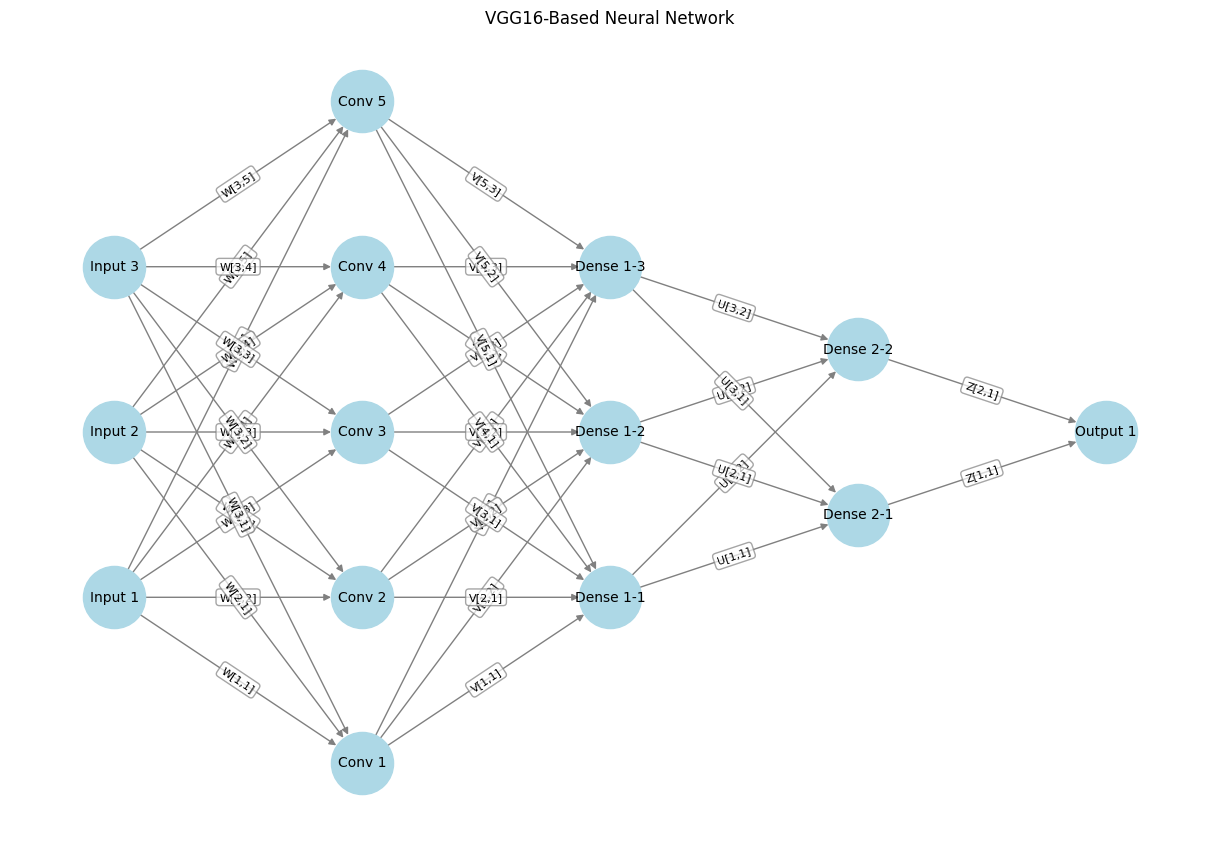

In [57]:
# Neural Network Visualization
def plot_vgg16_like_neural_network():
    """
    Plots a simplified neural network diagram inspired by the VGG16 architecture,
    showing non-overlapping weights and clear annotations.
    """

    # Create a directed graph
    G = nx.DiGraph()

    # Define layers with fewer neurons for visualization
    input_size = 3  # RGB input channels
    hidden_size_1 = 5  # Example for a reduced feature extractor
    hidden_size_2 = 3  # Dense layer 1 (128 neurons simplified)
    hidden_size_3 = 2  # Dense layer 2 (64 neurons simplified)
    output_size = 1  # Use the number of classes in the dataset

    # Add nodes for each layer
    for i in range(input_size):
        G.add_node(f"Input {i+1}", layer=0)

    for h1 in range(hidden_size_1):
        G.add_node(f"Conv {h1+1}", layer=1)

    for h2 in range(hidden_size_2):
        G.add_node(f"Dense 1-{h2+1}", layer=2)

    for h3 in range(hidden_size_3):
        G.add_node(f"Dense 2-{h3+1}", layer=3)

    for o in range(output_size):
        G.add_node(f"Output {o+1}", layer=4)

    # Add edges with symbolic weights between layers
    edge_labels = {}
    for i in range(input_size):
        for h1 in range(hidden_size_1):
            edge_label = f"W[{i+1},{h1+1}]"
            G.add_edge(f"Input {i+1}", f"Conv {h1+1}")
            edge_labels[(f"Input {i+1}", f"Conv {h1+1}")] = edge_label

    for h1 in range(hidden_size_1):
        for h2 in range(hidden_size_2):
            edge_label = f"V[{h1+1},{h2+1}]"
            G.add_edge(f"Conv {h1+1}", f"Dense 1-{h2+1}")
            edge_labels[(f"Conv {h1+1}", f"Dense 1-{h2+1}")] = edge_label

    for h2 in range(hidden_size_2):
        for h3 in range(hidden_size_3):
            edge_label = f"U[{h2+1},{h3+1}]"
            G.add_edge(f"Dense 1-{h2+1}", f"Dense 2-{h3+1}")
            edge_labels[(f"Dense 1-{h2+1}", f"Dense 2-{h3+1}")] = edge_label

    for h3 in range(hidden_size_3):
        for o in range(output_size):
            edge_label = f"Z[{h3+1},{o+1}]"
            G.add_edge(f"Dense 2-{h3+1}", f"Output {o+1}")
            edge_labels[(f"Dense 2-{h3+1}", f"Output {o+1}")] = edge_label

    # Define positions for a layered layout
    pos = {}
    layer_dist = 1.5  # Distance between layers
    node_dist = 1  # Distance between nodes

    # Position nodes for each layer
    for i in range(input_size):
        pos[f"Input {i+1}"] = (0, i * node_dist - (input_size - 1) * node_dist / 2)

    for h1 in range(hidden_size_1):
        pos[f"Conv {h1+1}"] = (layer_dist, h1 * node_dist - (hidden_size_1 - 1) * node_dist / 2)

    for h2 in range(hidden_size_2):
        pos[f"Dense 1-{h2+1}"] = (2 * layer_dist, h2 * node_dist - (hidden_size_2 - 1) * node_dist / 2)

    for h3 in range(hidden_size_3):
        pos[f"Dense 2-{h3+1}"] = (3 * layer_dist, h3 * node_dist - (hidden_size_3 - 1) * node_dist / 2)

    for o in range(output_size):
        pos[f"Output {o+1}"] = (4 * layer_dist, o * node_dist - (output_size - 1) * node_dist / 2)

    # Plot the network
    plt.figure(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        edge_color="gray",
        node_size=2000,
        font_size=10,
    )

    # Draw edge labels for symbolic weights with adjusted positioning to avoid overlap
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.7),
        label_pos=0.5,  # Place labels at the midpoint of the edges
    )
    plt.title("VGG16-Based Neural Network")
    plt.show()

# Call the function to plot the network
plot_vgg16_like_neural_network()
